# Dual-Stream Sign Language Recognition — WLASL-100
### COMP 5405 — Group 11 | yche0044 · ajaw0192 · jmar0565

**Dataset:** WLASL-100 — 100 most common ASL words, ~2,000 video clips  
**Task:** Isolated word recognition (video → predicted ASL word label)  
**Architecture:** Dual-Stream (RGB + Keypoint) → DSFF → TBT → Classifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

#WLASL_ROOT = Path('/content/drive/My Drive/Colab Notebooks/archive-2')
WLASL_ROOT = Path('/content/drive/My Drive/Colab Notebooks/Sign_Language_Recognition/archive')

if WLASL_ROOT.exists() and WLASL_ROOT.is_dir():
    print(f"Contents of '{WLASL_ROOT}':")
    for item in sorted(os.listdir(WLASL_ROOT)):
        print(f"- {item}")
else:
    print(f"Error: Folder '{WLASL_ROOT}' not found or is not a directory.")

# Verify required files exist
json_file  = WLASL_ROOT / 'WLASL_v0.3.json'
video_dir  = WLASL_ROOT / 'videos'
assert json_file.exists(),  f'JSON not found at {json_file}'
assert video_dir.exists(),  f'videos/ folder not found at {video_dir}'

n_videos = len(list(video_dir.glob('*.mp4')))
print(f'\n WLASL ready — {n_videos} .mp4 files found.')

Contents of '/content/drive/My Drive/Colab Notebooks/Sign_Language_Recognition':


AssertionError: JSON not found at /content/drive/My Drive/Colab Notebooks/Sign_Language_Recognition/WLASL_v0.3.json

## Cell 1 — Install Dependencies

In [ ]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
#!pip install mediapipe==0.10.13 opencv-python-headless einops matplotlib tqdm pandas kagglehub scikit-learn -q

print('All dependencies installed.')

All dependencies installed.


In [ ]:
!pip show mediapipe

Name: mediapipe
Version: 0.10.13
Summary: MediaPipe is the simplest way for researchers and developers to build world-class ML solutions and applications for mobile, edge, cloud and the web.
Home-page: https://github.com/google/mediapipe
Author: The MediaPipe Authors
Author-email: mediapipe@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, attrs, flatbuffers, jax, jaxlib, matplotlib, numpy, opencv-contrib-python, protobuf, sounddevice
Required-by: 


## Cell 3 — Imports & Config

In [ ]:
import json, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import mediapipe as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from einops import rearrange

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# Configuration
CFG = {
    # Dataset
    'wlasl_root':    str(WLASL_ROOT),
    'top_k':         100,               # use top-100 glosses
    'val_split':     0.15,              # 15% validation
    'test_split':    0.10,              # 10% test

    # Video preprocessing
    'max_frames':    64,                # frames per clip
    'frame_size':    (112, 112),        # H x W

    # Keypoint extraction
    'kp_cache_dir':  './kp_cache',      # save extracted keypoints to avoid re-computing

    # Stream A — RGB
    'd_model':       512,
    'vit_layers':    2,
    'vit_heads':     4,

    # Stream B — Keypoint
    'stgcn_channels': [32, 64, 128],

    # TBT
    'tbt_layers':    2,
    'tbt_heads':     4,
    'lambda_tbt':    0.3,

    # Classifier output dim
    'dec_hidden':    256,

    # Training
    'epochs':        25,
    'batch_size':    8,
    'lr':            3e-4,
    'weight_decay':  1e-4,
    'grad_clip':     1.0,
    'warmup_steps':  100,
    'label_smoothing': 0.1,

    # Output
    'checkpoint_dir': './checkpoints',
    'results_dir':    './results',
}

Path(CFG['kp_cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['checkpoint_dir']).mkdir(parents=True, exist_ok=True)
Path(CFG['results_dir']).mkdir(parents=True, exist_ok=True)
print('Config ready.')

Device : cpu
Config ready.


## Cell 4 — Explore the WLASL-100 Dataset

Classes       : 100
Total clips   : 972
Missing videos: 1066
Avg per class : 9.7


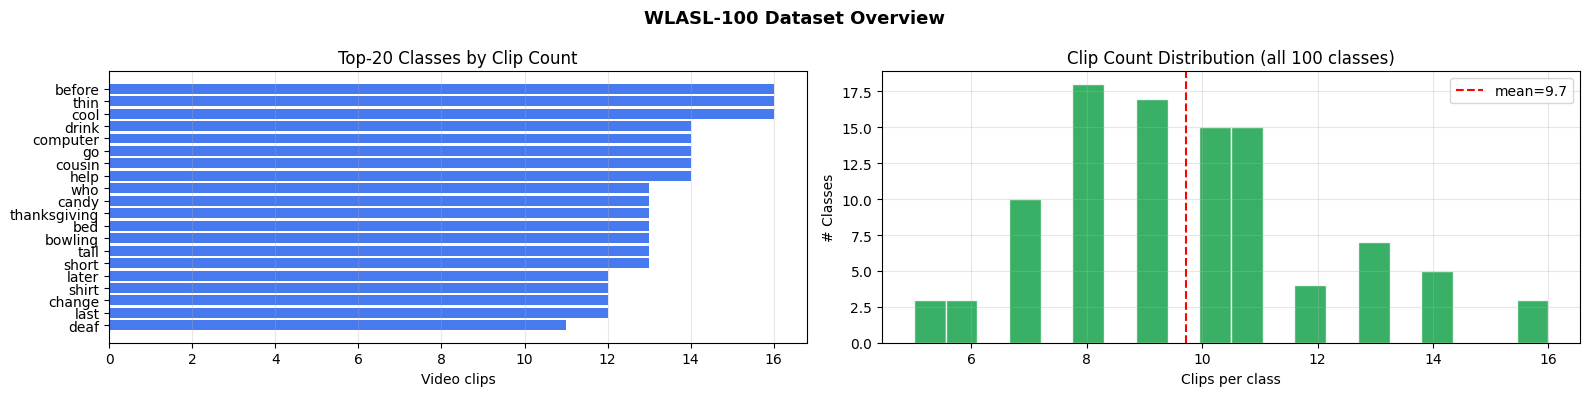


Top-5 classes: ['before', 'thin', 'cool', 'drink', 'computer']


In [ ]:
json_path = Path(CFG['wlasl_root']) / 'WLASL_v0.3.json'
with open(json_path) as f:
    wlasl_data = json.load(f)

# Sort by number of instances (most → least)
wlasl_data.sort(key=lambda x: len(x['instances']), reverse=True)
top100 = wlasl_data[:CFG['top_k']]

# Build class mapping
CLASS2IDX = {entry['gloss']: i for i, entry in enumerate(top100)}
IDX2CLASS = {v: k for k, v in CLASS2IDX.items()}
N_CLASSES  = len(CLASS2IDX)
CFG['n_classes'] = N_CLASSES

# Count available videos
video_dir   = Path(CFG['wlasl_root']) / 'videos'
all_samples = []
missing     = 0
for entry in top100:
    gloss = entry['gloss']
    for inst in entry['instances']:
        vid = video_dir / f"{inst['video_id']}.mp4"
        if vid.exists():
            all_samples.append({'path': str(vid),
                                 'label': CLASS2IDX[gloss],
                                 'gloss': gloss})
        else:
            missing += 1

print(f'Classes       : {N_CLASSES}')
print(f'Total clips   : {len(all_samples)}')
print(f'Missing videos: {missing}')
print(f'Avg per class : {len(all_samples) / N_CLASSES:.1f}')

# Distribution plot
counts = Counter(s['gloss'] for s in all_samples)
top20  = counts.most_common(20)
labels_p, vals_p = zip(*top20)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].barh(labels_p[::-1], vals_p[::-1], color='#2563EB', alpha=0.85)
axes[0].set_xlabel('Video clips')
axes[0].set_title('Top-20 Classes by Clip Count')
axes[0].grid(axis='x', alpha=0.3)

all_counts = list(counts.values())
axes[1].hist(all_counts, bins=20, color='#16A34A', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(all_counts), color='red', linestyle='--',
                label=f'mean={np.mean(all_counts):.1f}')
axes[1].set_xlabel('Clips per class')
axes[1].set_ylabel('# Classes')
axes[1].set_title('Clip Count Distribution (all 100 classes)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('WLASL-100 Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/dataset_overview.png", dpi=150)
plt.show()

print(f'\nTop-5 classes: {[g for g, _ in top20[:5]]}')

## Cell 5 — Pre-Extract MediaPipe Keypoints (Run Once, Then Cached)

In [ ]:
import os

if os.path.exists(CFG['kp_cache_dir']):
    print(f"Contents of '{CFG['kp_cache_dir']}':")
    for item in os.listdir(CFG['kp_cache_dir']):
        print(f"- {item}")
else:
    print(f"Directory '{CFG['kp_cache_dir']}' does not exist.")

Contents of './kp_cache':
- 17720.npy
- 12316.npy
- 12338.npy
- 07099.npy
- 17712.npy
- 17733.npy
- 17723.npy
- 12312.npy
- 12319.npy
- 17709.npy
- 12328.npy
- 17722.npy
- 12315.npy
- 12311.npy
- 17724.npy
- 07074.npy
- 12313.npy
- 12318.npy
- 07070.npy
- 17710.npy
- 07069.npy
- 17711.npy
- 12314.npy
- 07068.npy
- 65539.npy
- 17734.npy
- 65540.npy
- 17721.npy
- 17713.npy
- 12317.npy


In [ ]:
class KeypointExtractor:
    """Extracts 543 MediaPipe Holistic keypoints per frame."""

    BODY  = 33    # pose landmarks
    FACE  = 468   # face mesh
    HAND  = 21    # per hand (left + right)
    TOTAL = 33 + 468 + 21 + 21  # = 543

    def __init__(self):
        self.holistic = mp.solutions.holistic.Holistic(
            static_image_mode=False, model_complexity=1,
            refine_face_landmarks=True,
            min_detection_confidence=0.5, min_tracking_confidence=0.5
        )

    def _lm(self, landmark_list, n):
        # Initialize with n zero-landmarks to ensure consistent shape
        lms = [[0.0, 0.0, 0.0]] * n
        if landmark_list:
            # If landmarks are detected, populate up to 'n' landmarks
            for i, lm in enumerate(landmark_list.landmark):
                if i < n:
                    lms[i] = [lm.x, lm.y, lm.z]
                else:
                    # Stop if more landmarks are provided than expected 'n'
                    # This case is less common for MediaPipe, but handles robustness
                    break
        return lms

    def extract_frame(self, bgr):
        """Returns (543, 3) float32 array."""
        r = self.holistic.process(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        pts = (self._lm(r.pose_landmarks, self.BODY)
             + self._lm(r.face_landmarks, self.FACE)
             + self._lm(r.left_hand_landmarks, self.HAND)
             + self._lm(r.right_hand_landmarks, self.HAND))
        return np.array(pts, dtype=np.float32)  # (543, 3)

    def extract_video(self, path, max_frames):
        """Returns (T, 543, 3). Pads to max_frames with zeros."""
        cap    = cv2.VideoCapture(str(path))
        frames = []
        while cap.isOpened() and len(frames) < max_frames:
            ret, fr = cap.read()
            if not ret:
                break
            frames.append(self.extract_frame(fr))
        cap.release()
        T_real = len(frames)
        if T_real == 0:
            return np.zeros((max_frames, self.TOTAL, 3), dtype=np.float32), 0
        pad = [np.zeros((self.TOTAL, 3), dtype=np.float32)] * (max_frames - T_real)
        return np.stack(frames + pad), T_real

    def close(self):
        self.holistic.close()

Cache directory: ./kp_cache
This runs MediaPipe on every video once. Takes ~5-15 min for 2,000 clips.
Re-running is instant because results are cached.



Extracting keypoints:   7%|▋         | 64/972 [03:49<54:11,  3.58s/it]  


KeyboardInterrupt: 

In [ ]:
def preextract_all_keypoints(samples, cache_dir, max_frames, force=False):
    """
    Runs MediaPipe once on every video and saves .npy files.
    Subsequent runs load from cache — skips already-processed videos.
    """
    cache_dir = Path(cache_dir)
    extractor = KeypointExtractor()
    skipped   = 0
    processed = 0

    for sample in tqdm(samples, desc='Extracting keypoints'):
        vid_id    = Path(sample['path']).stem
        npy_path  = cache_dir / f'{vid_id}.npy'

        if npy_path.exists() and not force:
            skipped += 1
            continue

        kp, _ = extractor.extract_video(sample['path'], max_frames)
        np.save(npy_path, kp)
        processed += 1

    extractor.close()
    print(f'Keypoints extracted: {processed} new  |  {skipped} already cached')


# Run extraction (skips already-done files automatically)
print(f'Cache directory: {CFG["kp_cache_dir"]}')
print('This runs MediaPipe on every video once. Takes ~5-15 min for 2,000 clips.')
print('Re-running is instant because results are cached.\n')

preextract_all_keypoints(all_samples, CFG['kp_cache_dir'], CFG['max_frames'])
print('Keypoint extraction complete.')

Cache directory: ./kp_cache
This runs MediaPipe on every video once. Takes ~5-15 min for 2,000 clips.
Re-running is instant because results are cached.



Extracting keypoints:  91%|█████████ | 885/972 [1:34:05<10:09,  7.00s/it]

## Cell 6 — Dataset Class & DataLoaders

In [ ]:
RGB_TRANSFORM = T.Compose([
    T.ToPILImage(),
    T.Resize(CFG['frame_size']),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

RGB_TRANSFORM_TRAIN = T.Compose([
    T.ToPILImage(),
    T.Resize(CFG['frame_size']),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class WLASL100Dataset(Dataset):
    """
    WLASL-100 dataset loader.
    Loads RGB frames from .mp4 and pre-extracted keypoints from .npy cache.
    """

    def __init__(self, samples, kp_cache_dir, max_frames, augment=False):
        self.samples      = samples
        self.kp_cache_dir = Path(kp_cache_dir)
        self.max_frames   = max_frames
        self.transform    = RGB_TRANSFORM_TRAIN if augment else RGB_TRANSFORM

    def __len__(self):
        return len(self.samples)

    def _load_rgb(self, path):
        cap    = cv2.VideoCapture(str(path))
        frames = []
        while cap.isOpened() and len(frames) < self.max_frames:
            ret, fr = cap.read()
            if not ret:
                break
            frames.append(self.transform(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)))
        cap.release()
        T_real = len(frames)
        if T_real == 0:
            return torch.zeros(self.max_frames, 3, *CFG['frame_size']), 0
        pad = [torch.zeros(3, *CFG['frame_size'])] * (self.max_frames - T_real)
        return torch.stack(frames + pad), T_real

    def _load_kp(self, vid_id):
        npy = self.kp_cache_dir / f'{vid_id}.npy'
        if npy.exists():
            return torch.from_numpy(np.load(npy))   # (T, 543, 3)
        return torch.zeros(self.max_frames, 543, 3)

    def __getitem__(self, idx):
        s      = self.samples[idx]
        vid_id = Path(s['path']).stem

        rgb, T_real = self._load_rgb(s['path'])        # (T, 3, H, W)
        kp          = self._load_kp(vid_id)             # (T, 543, 3)

        mask        = torch.zeros(self.max_frames)
        mask[:T_real] = 1.0

        return {
            'rgb':   rgb,
            'kp':    kp,
            'label': torch.tensor(s['label'], dtype=torch.long),
            'gloss': s['gloss'],
            'mask':  mask,
        }


# Train / Val / Test split
random.shuffle(all_samples)
n      = len(all_samples)
n_test = int(n * CFG['test_split'])
n_val  = int(n * CFG['val_split'])
n_train= n - n_val - n_test

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train : n_train + n_val]
test_samples  = all_samples[n_train + n_val:]

print(f'Split  →  Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

train_ds = WLASL100Dataset(train_samples, CFG['kp_cache_dir'],
                            CFG['max_frames'], augment=True)
val_ds   = WLASL100Dataset(val_samples,   CFG['kp_cache_dir'],
                            CFG['max_frames'], augment=False)
test_ds  = WLASL100Dataset(test_samples,  CFG['kp_cache_dir'],
                            CFG['max_frames'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready.')

Split  →  Train: 730 | Val: 145 | Test: 97
DataLoaders ready.


## Cell 7 — Visualise Sample Clips

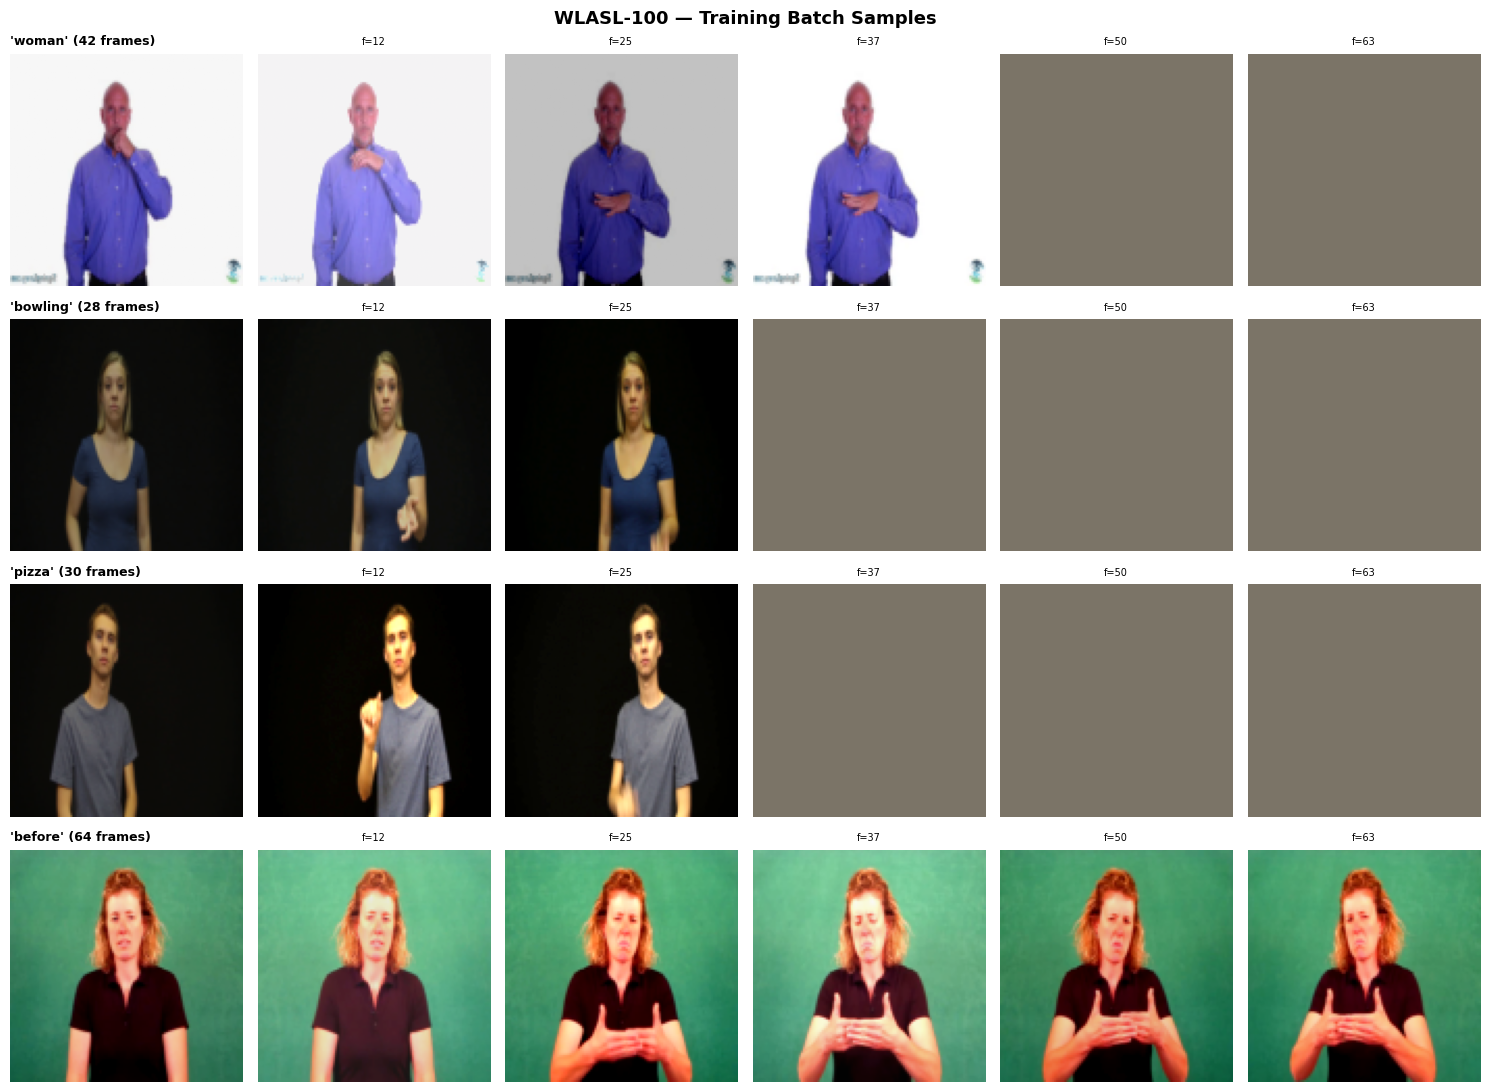

Keypoint shape : torch.Size([64, 543, 3])  (T=64, N=543, coords=3)
Valid frames   : 42
KP x range     : [0.000, 0.726]
KP y range     : [0.000, 2.029]


In [ ]:
def denorm(t):
    m = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    s = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t * s + m).clamp(0, 1)


batch = next(iter(train_loader))
B     = min(4, batch['rgb'].size(0))
N_FRAMES_SHOW = 6
idxs  = np.linspace(0, CFG['max_frames'] - 1, N_FRAMES_SHOW, dtype=int)

fig, axes = plt.subplots(B, N_FRAMES_SHOW, figsize=(15, 2.8 * B))
if B == 1: axes = axes[np.newaxis, :]

for row in range(B):
    gloss  = batch['gloss'][row]
    T_real = int(batch['mask'][row].sum().item())
    for col, fi in enumerate(idxs):
        frame = denorm(batch['rgb'][row, fi]).permute(1, 2, 0).numpy()
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f"'{gloss}' ({T_real} frames)",
                                      fontsize=9, loc='left', fontweight='bold')
        else:
            axes[row, col].set_title(f'f={fi}', fontsize=7)

plt.suptitle('WLASL-100 — Training Batch Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/sample_clips.png", dpi=150)
plt.show()

# Keypoint quick check
kp = batch['kp'][0]  # (T, 543, 3)
T_real = int(batch['mask'][0].sum())
print(f"Keypoint shape : {kp.shape}  (T={CFG['max_frames']}, N=543, coords=3)")
print(f"Valid frames   : {T_real}")
print(f"KP x range     : [{kp[:T_real,:,0].min():.3f}, {kp[:T_real,:,0].max():.3f}]")
print(f"KP y range     : [{kp[:T_real,:,1].min():.3f}, {kp[:T_real,:,1].max():.3f}]")

## Cell 8 — Model Architecture

In [ ]:
# Stream A: RGB Appearance (ResNet-50 + ViT)
class RGBStream(nn.Module):
    """Eq.(1) in proposal: Z^A = ViT(v1,...,vT) ∈ R^{T×d}"""

    def __init__(self, d_model, vit_layers, vit_heads, max_frames):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Freeze early layers, fine-tune layer3 and layer4
        for name, p in resnet.named_parameters():
            if not any(x in name for x in ['layer3', 'layer4', 'fc']):
                p.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # -> (B,2048,1,1)
        self.proj     = nn.Linear(2048, d_model)
        self.pos_emb  = nn.Parameter(torch.randn(1, max_frames, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model, vit_heads, d_model * 2, 0.1,
            batch_first=True, norm_first=True
        )
        self.vit  = nn.TransformerEncoder(enc, vit_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, rgb, mask=None):
        B, T = rgb.shape[:2]
        x = rearrange(rgb, 'b t c h w -> (b t) c h w')
        x = self.backbone(x).flatten(1)          # (B*T, 2048)
        x = self.proj(x)                          # (B*T, d)
        x = rearrange(x, '(b t) d -> b t d', b=B, t=T)
        x = x + self.pos_emb[:, :T]
        kpm = (mask == 0) if mask is not None else None
        return self.norm(self.vit(x, src_key_padding_mask=kpm))  # (B, T, d)


In [ ]:
# Stream B: Dense Keypoint Graph (ST-GCN + BiLSTM)
class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_kernel=5):
        super().__init__()
        self.gcn  = nn.Conv1d(in_ch, out_ch, 1)
        self.tcn  = nn.Sequential(
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, t_kernel,
                      padding=t_kernel // 2),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.tcn(self.gcn(x)) + self.skip(x))


class KeypointStream(nn.Module):
    """Eq.(2) in proposal: Z^B = BiLSTM(STGCN(G1,...,GT)) ∈ R^{T×d}"""

    def __init__(self, d_model, channels):
        super().__init__()
        layers, in_ch = [], 3
        for out_ch in channels:
            layers.append(STGCNBlock(in_ch, out_ch))
            in_ch = out_ch
        self.stgcn  = nn.Sequential(*layers)
        self.bilstm = nn.LSTM(
            channels[-1], d_model // 2, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.1
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, kp):
        B, T, N, C = kp.shape
        x = rearrange(kp, 'b t n c -> (b n) c t')  # node-wise ST-GCN
        x = self.stgcn(x)                            # (B*N, ch, T)
        x = rearrange(x, '(b n) c t -> b n c t', b=B, n=N).mean(1)  # pool nodes
        x = rearrange(x, 'b c t -> b t c')           # (B, T, ch)
        out, _ = self.bilstm(x)                      # (B, T, d)
        return self.norm(out)


In [ ]:
# DSFF: Dual-Stream Feature Fusion
class DSFF(nn.Module):
    """Eq.(4,5) in the proposal: Cross-modal attention + projection."""

    def __init__(self, d_model, nhead, out_dim):
        super().__init__()
        self.ca_A  = nn.MultiheadAttention(d_model, nhead, 0.1, batch_first=True)
        self.ca_B  = nn.MultiheadAttention(d_model, nhead, 0.1, batch_first=True)
        self.proj  = nn.Linear(2 * d_model, out_dim)
        self.normA = nn.LayerNorm(d_model)
        self.normB = nn.LayerNorm(d_model)
        self.norm  = nn.LayerNorm(out_dim)

    def forward(self, A, B, key_mask=None):
        At, _ = self.ca_A(A, B, B, key_padding_mask=key_mask)
        Bt, _ = self.ca_B(B, A, A, key_padding_mask=key_mask)
        At = self.normA(A + At)
        Bt = self.normB(B + Bt)
        return self.norm(self.proj(torch.cat([At, Bt], dim=-1)))


# TBT: Temporal Boundary Transformer
class TBT(nn.Module):
    """Eq.(3): Binary sequence labelling for sign boundaries."""

    def __init__(self, d_model, n_layers, nhead):
        super().__init__()
        enc = nn.TransformerEncoderLayer(
            d_model, nhead, d_model, 0.1,
            batch_first=True, norm_first=True
        )
        self.enc  = nn.TransformerEncoder(enc, n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x, mask=None):
        kpm = (mask == 0) if mask is not None else None
        z   = self.enc(x, src_key_padding_mask=kpm)
        p_t = self.head(z).squeeze(-1)  # (B, T) boundary probs
        return p_t, z

    @staticmethod
    def bce_loss(p_t, y_t, mask):
        loss = F.binary_cross_entropy(p_t, y_t.float(), reduction='none')
        return (loss * mask).sum() / mask.sum().clamp(min=1)


In [ ]:

# Classification Head
class ClassHead(nn.Module):
    """Masked global average pool → MLP classifier."""

    def __init__(self, d_model, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(d_model, n_classes)
        )

    def forward(self, z, mask=None):
        if mask is not None:
            me = mask.unsqueeze(-1)                        # (B, T, 1)
            pooled = (z * me).sum(1) / me.sum(1).clamp(min=1)
        else:
            pooled = z.mean(1)
        return self.mlp(pooled)                            # (B, n_classes)


# Full Dual-Stream Model
class DualStreamSLR(nn.Module):
    """
    Full pipeline for WLASL-100 sign language recognition.
    Stream A + Stream B -> DSFF -> TBT -> ClassHead
    Loss: L_total = L_CE + λ * L_TBT  (Eq. 7)
    """

    def __init__(self, cfg):
        super().__init__()
        d  = cfg['d_model']
        dd = cfg['dec_hidden']
        self.stream_a = RGBStream(d, cfg['vit_layers'],
                                   cfg['vit_heads'], cfg['max_frames'])
        self.stream_b = KeypointStream(d, cfg['stgcn_channels'])
        self.dsff     = DSFF(d, 4, dd)
        self.tbt      = TBT(dd, cfg['tbt_layers'], cfg['tbt_heads'])
        self.head     = ClassHead(dd, cfg['n_classes'])
        self.lambda_b = cfg['lambda_tbt']

    def forward(self, rgb, kp, mask=None):
        Z_A    = self.stream_a(rgb, mask)               # (B, T, d)
        Z_B    = self.stream_b(kp)                      # (B, T, d)
        km     = (mask == 0) if mask is not None else None
        Z_f    = self.dsff(Z_A, Z_B, km)                # (B, T, dd)
        p_t, Z_e = self.tbt(Z_f, mask)                  # (B,T), (B,T,dd)
        logits = self.head(Z_e, mask)                   # (B, n_classes)
        return logits, p_t

    def loss(self, logits, labels, p_t, bnd_labels, mask, label_smoothing=0.1):
        cls = F.cross_entropy(logits, labels, label_smoothing=label_smoothing)
        bnd = TBT.bce_loss(p_t, bnd_labels, mask)
        return cls + self.lambda_b * bnd, cls.item(), bnd.item()


# Instantiate
model = DualStreamSLR(CFG).to(DEVICE)

def count(m): return sum(p.numel() for p in m.parameters())
def count_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('\n🏗️  Architecture:')
for name, sub in [('Stream A (ResNet+ViT)', model.stream_a),
                   ('Stream B (STGCN+BiLSTM)', model.stream_b),
                   ('DSFF', model.dsff),
                   ('TBT', model.tbt),
                   ('ClassHead', model.head)]:
    print(f'  {name:24s}  {count(sub):>10,} params')
print(f'  {"TOTAL":24s}  {count(model):>10,} params')
print(f'  {"TRAINABLE":24s}  {count_trainable(model):>10,} params')
print(f'\nClasses: {N_CLASSES}')
print('Model ready.')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 117MB/s]



🏗️  Architecture:
  Stream A (ResNet+ViT)     28,796,480 params
  Stream B (STGCN+BiLSTM)    2,498,272 params
  DSFF                       2,366,208 params
  TBT                          808,065 params
  ClassHead                     91,492 params
  TOTAL                     34,560,517 params
  TRAINABLE                 33,115,589 params

Classes: 100
Model ready.


## Cell 9 — Training

In [ ]:
def make_boundary_labels(mask, n_bounds=5):
    """Uniform pseudo-boundary labels within valid frames."""
    B, T   = mask.shape
    labels = torch.zeros(B, T, device=mask.device)
    step   = max(1, T // (n_bounds + 1))
    for i in range(1, n_bounds + 1):
        labels[:, min(i * step, T - 1)] = 1.0
    return labels * mask


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        rgb    = batch['rgb'].to(device)
        kp     = batch['kp'].to(device)
        labels = batch['label'].to(device)
        mask   = batch['mask'].to(device)
        bnd_y  = make_boundary_labels(mask)

        optimizer.zero_grad()
        logits, p_t = model(rgb, kp, mask)
        loss, _, _  = model.loss(logits, labels, p_t, bnd_y, mask,
                                  CFG['label_smoothing'])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        tot_loss += loss.item() * labels.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    return tot_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        rgb    = batch['rgb'].to(device)
        kp     = batch['kp'].to(device)
        labels = batch['label'].to(device)
        mask   = batch['mask'].to(device)
        logits, _ = model(rgb, kp, mask)
        preds  = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return correct / total, all_preds, all_labels


# Scheduler with linear warmup + cosine decay
optimizer   = torch.optim.AdamW(model.parameters(),
                                  lr=CFG['lr'], weight_decay=CFG['weight_decay'])
total_steps = CFG['epochs'] * len(train_loader)

def lr_lambda(step):
    w = CFG['warmup_steps']
    if step < w:
        return step / max(1, w)
    p = (step - w) / max(1, total_steps - w)
    return max(0.0, 0.5 * (1 + math.cos(math.pi * p)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training loop
history  = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_acc = 0.0

print(f'Training for {CFG["epochs"]} epochs on {len(train_samples)} clips...\n')

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_acc, _, _   = eval_epoch(model, val_loader, DEVICE)
    cur_lr          = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc * 100)
    history['val_acc'].append(val_acc * 100)
    history['lr'].append(cur_lr)

    flag = ''
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({'epoch': epoch,
                    'state_dict': model.state_dict(),
                    'cfg': CFG,
                    'class2idx': CLASS2IDX},
                   f"{CFG['checkpoint_dir']}/best_wlasl100.pt")
        flag = '  ← best'

    print(f'Ep {epoch:02d}/{CFG["epochs"]} | '
          f'Loss {tr_loss:.4f} | '
          f'Train {tr_acc*100:.1f}% | '
          f'Val {val_acc*100:.1f}% | '
          f'LR {cur_lr:.2e}{flag}')

print(f'\n Training complete. Best Val Accuracy: {best_acc*100:.1f}%')

Training for 25 epochs on 730 clips...



KeyboardInterrupt: 

## Cell 10 — Training Curves

In [ ]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_x, history['train_loss'], color='#2563EB', marker='o', linewidth=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history['train_acc'], color='#16A34A', marker='o',
             linewidth=2, label='Train')
axes[1].plot(epochs_x, history['val_acc'],   color='#DC2626', marker='s',
             linewidth=2, linestyle='--', label='Val')
axes[1].axhline(best_acc * 100, color='orange', linestyle=':', linewidth=1.2,
                label=f'Best val={best_acc*100:.1f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history['lr'], color='#7C3AED', linewidth=2)
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR'); axes[2].grid(alpha=0.3)

plt.suptitle('WLASL-100 — Dual-Stream SLR Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/training_curves.png", dpi=150)
plt.show()

## Cell 11 — Test Set Evaluation & Confusion Matrix